In [1]:
import pandas as pd

# Load cleaned CSVs
benin = pd.read_csv(r"C:\Users\THINKPAD\Desktop\10_Academy\Week_0\solar-challenge-week0\data\benin_clean.csv", parse_dates=["Timestamp"])
sierra = pd.read_csv(r"C:\Users\THINKPAD\Desktop\10_Academy\Week_0\solar-challenge-week0\data\sieraleone_clean.csv", parse_dates=["Timestamp"])
togo = pd.read_csv(r"C:\Users\THINKPAD\Desktop\10_Academy\Week_0\solar-challenge-week0\data\togo_clean.csv", parse_dates=["Timestamp"])

# Add a 'Country' column for comparison
benin['Country'] = 'Benin'
sierra['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

# Combine into one DataFrame
df_all = pd.concat([benin, sierra, togo], ignore_index=True)
df_all.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,Country
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN,Benin
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN,Benin
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN,Benin
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN,Benin
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN,Benin


Metrics comparison - box plot

C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_20932\197236741.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='Country', y=metric, palette="Set2")


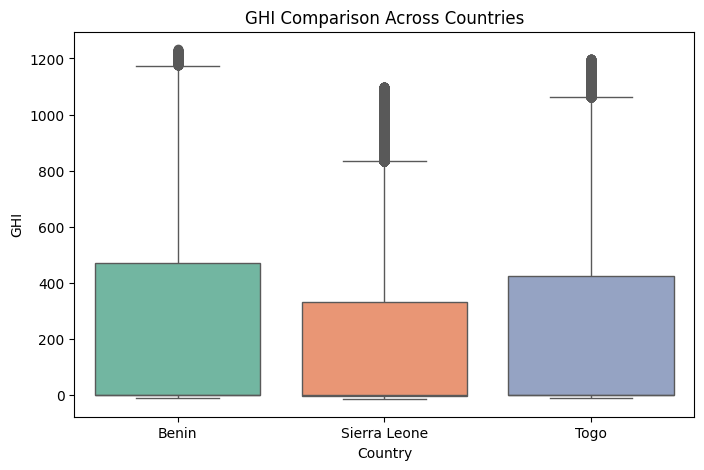

C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_20932\197236741.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='Country', y=metric, palette="Set2")


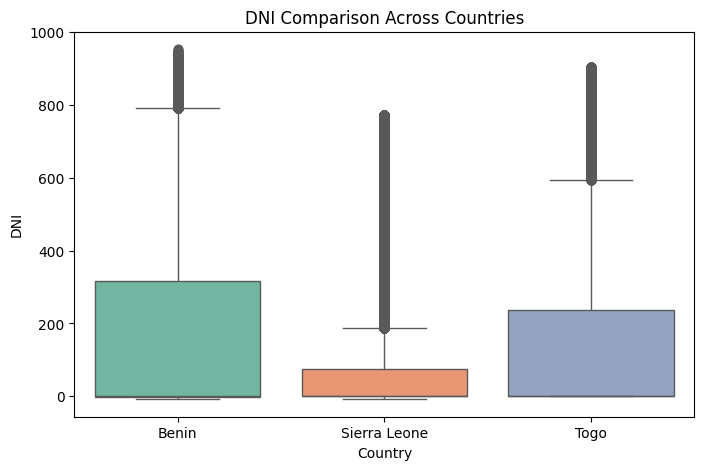

C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_20932\197236741.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='Country', y=metric, palette="Set2")


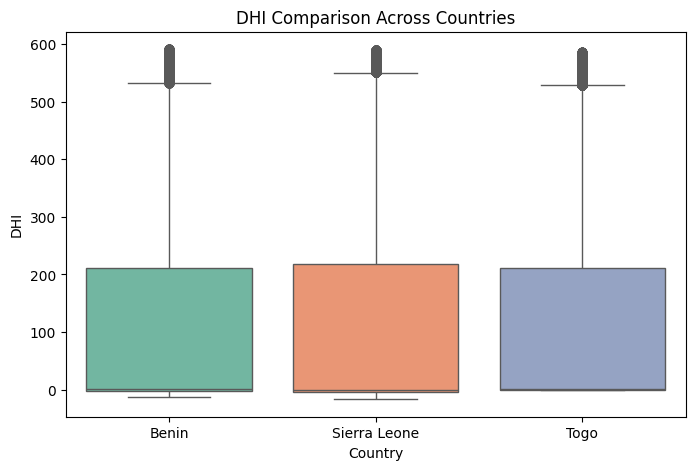

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['GHI', 'DNI', 'DHI']

for metric in metrics:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_all, x='Country', y=metric, palette="Set2")
    plt.title(f"{metric} Comparison Across Countries")
    plt.show()


summary table

In [3]:
summary = df_all.groupby('Country')[metrics].agg(['mean','median','std'])
summary


GHI                            DNI                     \
                    mean median         std        mean median         std   
Country                                                                      
Benin         236.234508    0.7  328.288787  166.896673   -0.1  262.081997   
Sierra Leone  185.000024   -0.4  279.019460  104.128943   -0.1  200.954182   
Togo          223.859675    0.5  317.306277  147.975931    0.0  247.683690   

                     DHI                     
                    mean median         std  
Country                                      
Benin         111.656477    0.5  153.099749  
Sierra Leone  108.104278   -0.6  153.691835  
Togo          112.781249    1.5  151.571744

In [4]:
from scipy.stats import f_oneway

stat, p = f_oneway(benin['GHI'], sierra['GHI'], togo['GHI'])
print(f"ANOVA F-statistic: {stat:.2f}, p-value: {p:.4f}")


ANOVA F-statistic: 3833.18, p-value: 0.0000


In [5]:
from scipy.stats import kruskal

stat, p = kruskal(benin['GHI'], sierra['GHI'], togo['GHI'])
print(f"Kruskal-Wallis H-statistic: {stat:.2f}, p-value: {p:.4f}")


Kruskal-Wallis H-statistic: 6548.53, p-value: 0.0000


Key Observations

Benin shows high median GHI but also considerable variability
Sierra Leone and benin has more stable DNI values compared to togo
Togo exhibits slightly lower DHI values on average indicating less diffuse radiation

C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_20932\2007356031.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_all, x='Country', y='GHI', palette='Set3')


<Axes: xlabel='Country', ylabel='GHI'>

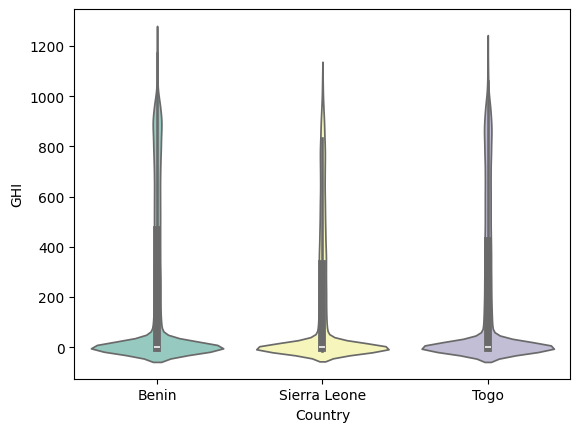

In [6]:
sns.violinplot(data=df_all, x='Country', y='GHI', palette='Set3')
